### Ejemplo de uso de los datos del dataset LATAM_PM2.5_1km
- Objetivo: Mostrar cómo leer, visualizar y extraer valores de los mapas anuales de PM2.5 predicho.

In [ ]:
# Librerías
import os
import rasterio
import geopandas as gpd
from shapely.geometry import Point
import folium
import numpy as np
import matplotlib.pyplot as plt
import re
import rioxarray
import xarray as xr
print("Librerias ok!")

Librerias ok!


In [ ]:
# 1. Directorio donde se encuentran las imágenes (.tif)
directorio = r"D:/Josefina/Proyectos/ProyectoChile/CH/modelos/Salidas/SalidasAnuales/01-XGB-CV-M1-190625-CH/base"

os.chdir(directorio)

# -------------------------------------------------------------
# 2. Listar todas las imágenes disponibles en el directorio
archivos = [f for f in os.listdir(directorio) if f.endswith('.tif')]
print(archivos)

# -----------------------------
# 3. Leer un raster (primer archivo por ejemplo)
# -----------------------------
if archivos:
    raster_path = archivos[0]
    print("Nombre archivo:", raster_path)
    with rasterio.open(raster_path) as src:
        #print(src.profile)  # información del raster
        raster_array = src.read(1)  # leer la primera banda
        # obtener bounds, resolución, CRS
        print("Bounds:", src.bounds)
        print("CRS:", src.crs)

print("Cantidad de archivos en el directorio: ",len(archivos)) 

['XGB_PM2.5_Y_2015_ST_V1.1.tif', 'XGB_PM2.5_Y_2016_ST_V1.1.tif', 'XGB_PM2.5_Y_2017_ST_V1.1.tif', 'XGB_PM2.5_Y_2018_ST_V1.1.tif', 'XGB_PM2.5_Y_2019_ST_V1.1.tif', 'XGB_PM2.5_Y_2020_ST_V1.1.tif', 'XGB_PM2.5_Y_2021_ST_V1.1.tif', 'XGB_PM2.5_Y_2022_ST_V1.1.tif', 'XGB_PM2.5_Y_2023_ST_V1.1.tif', 'XGB_PM2.5_Y_2024_ST_V1.1.tif']
Nombre archivo: XGB_PM2.5_Y_2015_ST_V1.1.tif
Bounds: BoundingBox(left=-70.82743734878598, bottom=-33.598559997305905, right=-70.50103734878597, top=-33.323669997305906)
CRS: EPSG:4326
Cantidad de archivos en el directorio:  10


In [26]:
# Abrir un solo raster sin 'with'
archivo_interes = r"XGB_PM2.5_Y_2015_ST_V1.1.tif"
src = rasterio.open(archivo_interes)
# Leer la primera banda
PM25_2015 = src.read(1)

# Información
print(src.profile)
print(src.bounds)
print(src.crs)

# ¡Ojo! Al final hay que cerrarlo explícitamente
src.close()


{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 32, 'height': 33, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.010200000000000209, 0.0, -70.82743734878598,
       0.0, -0.008329999999999976, -33.323669997305906), 'blockxsize': 32, 'blockysize': 33, 'tiled': False, 'compress': 'lzw', 'interleave': 'band'}
BoundingBox(left=-70.82743734878598, bottom=-33.598559997305905, right=-70.50103734878597, top=-33.323669997305906)
EPSG:4326


In [27]:
# 4. Metricas basicas de un solo raster

media_dominio = np.nanmean(PM25_2015)
sd_dominio = np.nanstd(PM25_2015)

print("Media:", round(media_dominio,2))
print("Desviación estándar:", round(sd_dominio,2))


Media: 24.68
Desviación estándar: 3.68


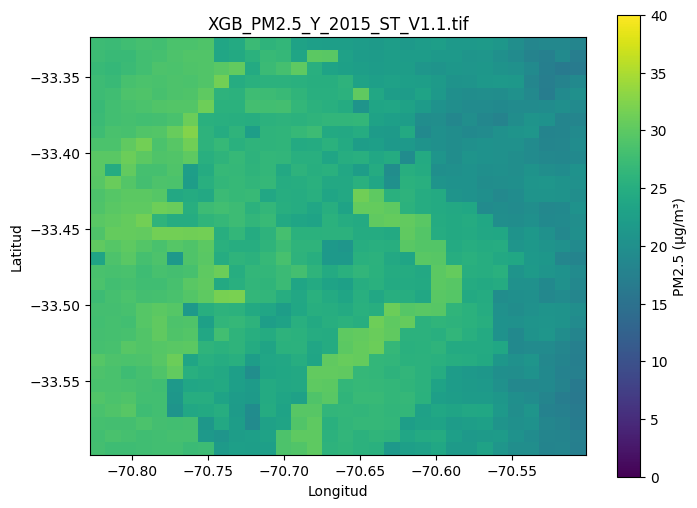

In [28]:
# 5. Visualización básica

plt.figure(figsize=(8,6))
plt.imshow(PM25_2015, cmap="viridis", vmin=0, vmax=40,
           extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])
plt.colorbar(label="PM2.5 (µg/m³)")
plt.title(archivo_interes)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.axis("on")  # para mostrar coordenadas geográficas
plt.show()


In [29]:
# 6. Extraer el valor de PM2.5 en un punto especifico
# Coordenadas de ejemplo (latitud, longitud) de Santiago centro
lon, lat = -70.6506, -33.4372

# Transformar coordenadas a índices de fila/columna
# -----------------------------
row, col = src.index(lon, lat)

# Extraer valor

valor_PM25 = PM25_2015[row, col]
print(f"Valor de PM2.5 en el punto elegido: {valor_PM25:.2f} µg/m³")

# Cerrar raster

src.close()


Valor de PM2.5 en el punto elegido: 30.59 µg/m³


In [ ]:
# 8. Leer todas las imagenes del directorio como un Stack 